<a href="https://colab.research.google.com/github/emmannuelltr/Analitica-de-Negocios/blob/main/Carpeta3/Diabetesproyect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**CASO DE ESTUDIO**

En este documento se desarrolla y analiza un modelo de analítica predictiva utilizando Naive Bayes, Árboles de Decisión y Clustering, para la detección de patrones que permitan clasificar pacientes con alto riesgo de padecer diabetes. El objetivo principal es apoyar a las entidades del sector salud en la identificación temprana de pacientes de riesgo, optimizando los recursos de diagnóstico y tratamiento preventivo.De acuerdo con lo anterior, las variables de salud analizadas son:

Pregnancies: Número de embarazos de la paciente.

Glucose: Concentración de glucosa plasmática a 2 horas en una prueba de tolerancia oral a la glucosa.

BloodPressure: Presión arterial diastólica (mm Hg).

SkinThickness: Espesor del pliegue cutáneo del tríceps (mm).

Insulin: Insulina sérica de 2 horas (mu U/ml).

BMI: Índice de masa corporal

DiabetesPedigreeFunction: Función que puntúa la probabilidad de diabetes basándose en antecedentes familiares.

Age: Edad en años del paciente.

Outcome: Variable de salida (1: posee diabetes, 0: no posee diabetes).

0. Se cargan librerías

In [ ]:
import numpy as np #Librería numérica por excelencia
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Librerias especifificas
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

1. Se carga base de datos

In [ ]:
XDB = pd.read_csv('/content/diabetes.csv')

#Seleccionamos variables de trabajo

XD = XDB.iloc[:, [0, 1, 2, 3, 4, 5, 6, 7]]
yd = XDB.iloc[:, [8]]

print("Variables de entrada seleccionadas (XD):")
print(XD.columns.tolist())

Variables de entrada seleccionadas (XD):
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


2. Análisis de correlación

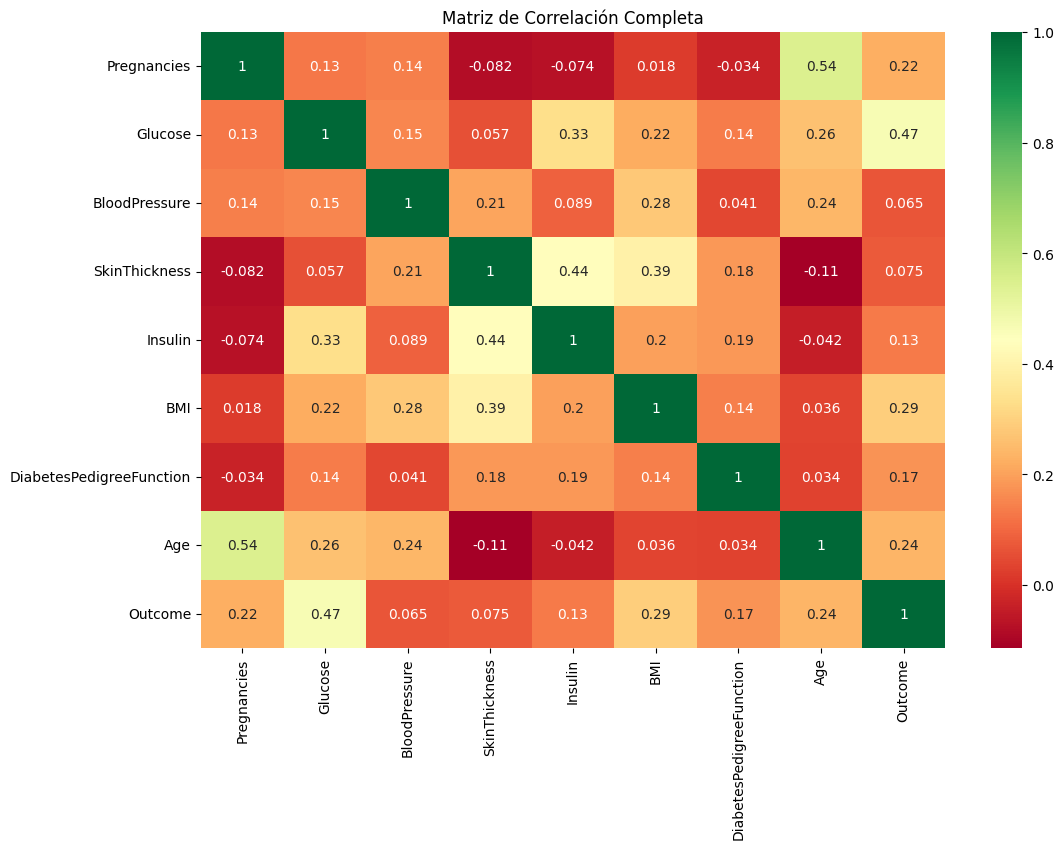

Correlación con la variable de salida (Outcome):
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [ ]:
# Creamos XDB2 con todas las columnas para el heatmap
XDB2 = XDB.iloc[:, [0, 1, 2, 3, 4, 5, 6, 7, 8]].copy()

plt.figure(figsize=(12, 8))
# Usamos annot=True para ver los valores numéricos
sns.heatmap(XDB2.corr(), annot=True, cmap='RdYlGn')
plt.title("Matriz de Correlación Completa")
plt.show()

# Identificación de la correlación con Outcome
print("Correlación con la variable de salida (Outcome):")
print(XDB2.corr()['Outcome'].sort_values(ascending=False))


En el heatmap muestra que la Glucosa (0.47) es el factor más determinante para identificar la diabetes, lo que significa que a mayores niveles de azúcar, el riesgo aumenta de forma directa. Le siguen en importancia el IMC (0.29) y la Edad (0.24), confirmando que el sobrepeso y el envejecimiento son variables críticas de riesgo. Por el contrario, la presión arterial y el grosor de la piel no presentan una relación fuerte con el diagnóstico, por lo que el modelo se apoyará principalmente en los niveles de glucosa y el perfil físico del paciente para tomar decisiones.

2. Modelo Naive Bayes e Identificación de Límites

In [ ]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(XD, yd)

# Entrenamiento del modelo
modelo_nb = GaussianNB()
modelo_nb.fit(X_train, y_train.values.ravel())

# CÁLCULO DE LÍMITES DE NEGOCIO
# Agrupamos por la variable objetivo para comparar comportamientos
medias = XDB2.groupby('Outcome').mean()
desviaciones = XDB2.groupby('Outcome').std()

# Calculamos límites superiores e inferiores
limite_inferior = medias - desviaciones
limite_superior = medias + desviaciones

print("LÍMITES INFERIORES POR GRUPO")
display(limite_inferior)

print("LÍMITES SUPERIORES POR GRUPO")
display(limite_superior)

LÍMITES INFERIORES POR GRUPO


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,0.280815,83.838800,50.120925,4.774053,-30.073289,22.614345,0.130649,19.522345
1,1.124433,109.317841,49.332815,4.484468,-38.353304,27.879570,0.178146,26.098911


LÍMITES SUPERIORES POR GRUPO


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,6.315185,136.121200,86.247075,34.553947,167.657289,37.994055,0.728819,42.857655
1,8.606911,173.197085,92.316439,39.843891,239.024946,42.405505,0.922854,48.035418


3. Contrucción árbol de  decisión

Matriz de confusión: 
 [[459  41]
 [119 149]]
Exactitud:  0.7916666666666666
Sensibilidad:  0.5559701492537313
Especificidad:  0.918
Precisión:  0.7842105263157895
Precisión Negativa:  0.7941176470588235


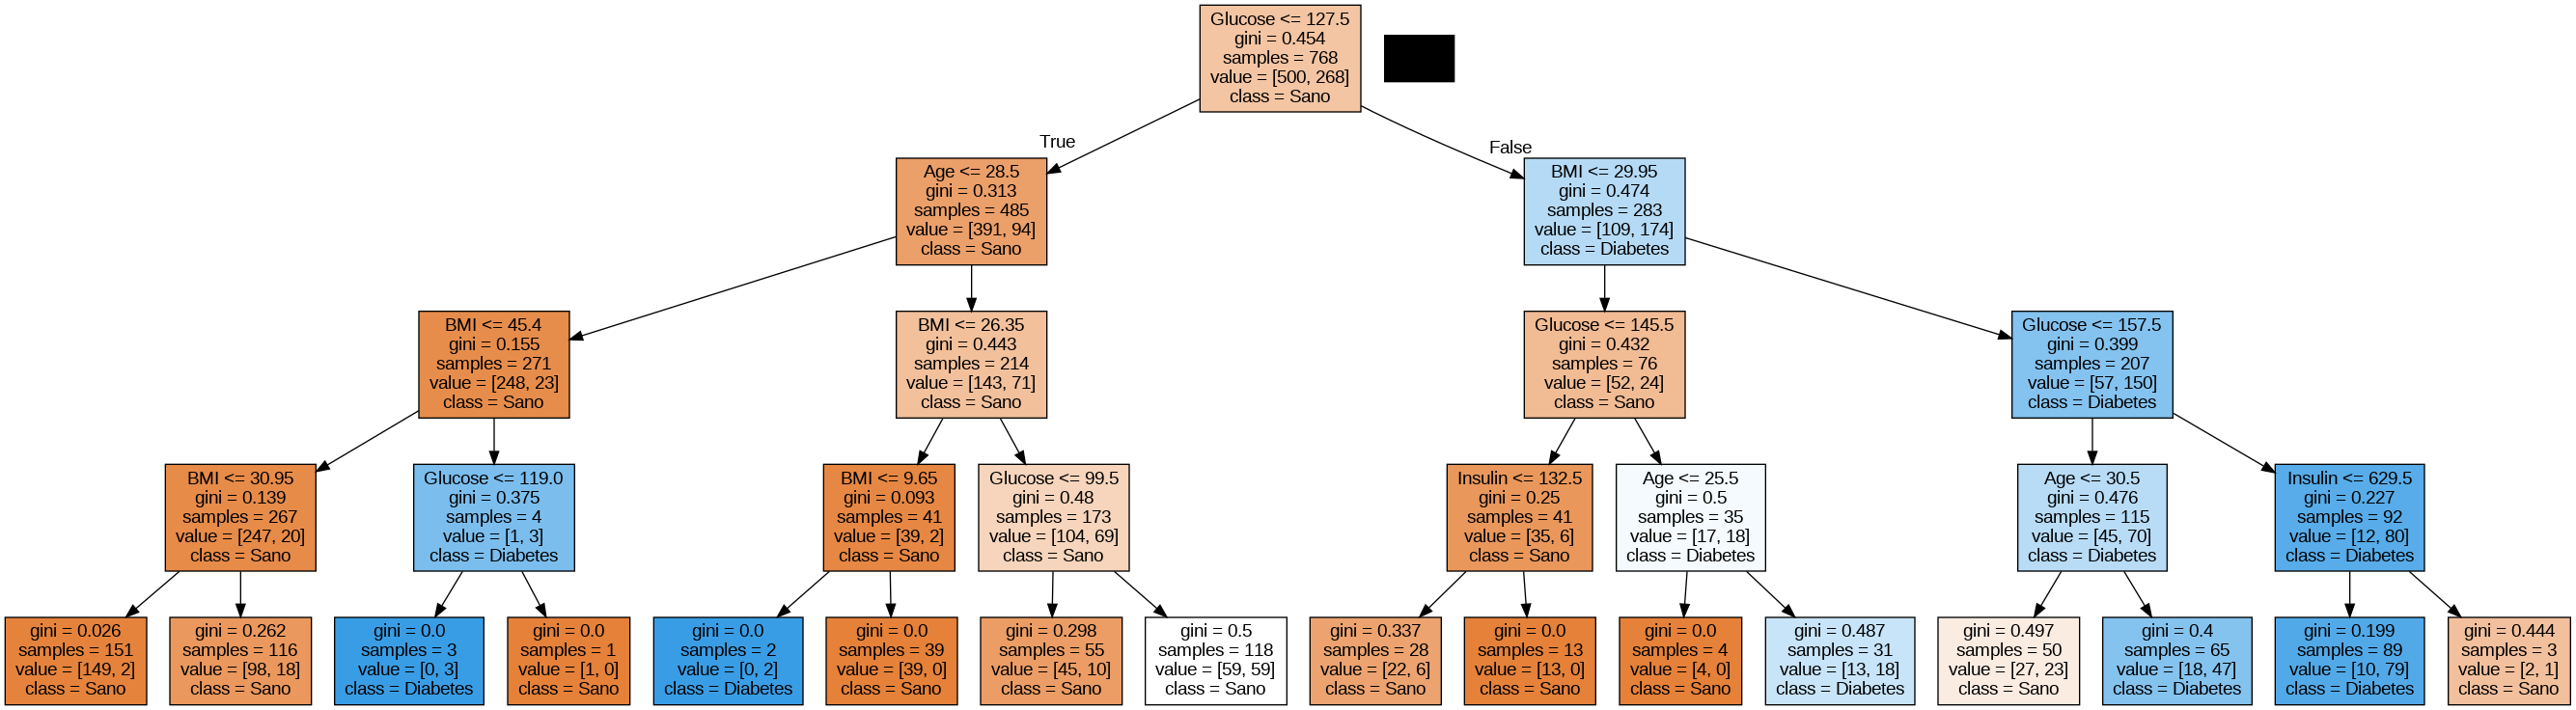

In [ ]:
from sklearn.tree import DecisionTreeClassifier, export_text, export_graphviz
from sklearn.metrics import confusion_matrix
import pydotplus
from IPython.display import Image

# 3.1. Entrenamiento del modelo
mar = DecisionTreeClassifier(criterion="gini", max_depth=4, random_state=1)
mar.fit(XD, yd) # Aquí el modelo busca relación entrada-salida

# 3.2. ¿Y qué fue lo que hizo el modelo?
ydp = mar.predict(XD) # Esto es lo que pronóstica el modelo

# Se construye la matriz de confusión
cm = confusion_matrix(yd, ydp)
VN = cm[0, 0]; FP = cm[0, 1]; FN = cm[1, 0]; VP = cm[1, 1]
print("Matriz de confusión: \n", cm)

# Métricas de desempeño
Ex = (VP + VN) / len(XD)
print("Exactitud: ", Ex)

Sen = VP / (VP + FN)
print("Sensibilidad: ", Sen)

Sp = VN / (VN + FP)
print("Especificidad: ", Sp)

Prec = VP / (VP + FP)
print("Precisión: ", Prec)

PreNeg = VN / (VN + FN)
print("Precisión Negativa: ", PreNeg)

# 3.5. Generación del gráfico del Árbol
# Títulos de las variables de salud
vc = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "Pedigree", "Age"]

dot_data = export_graphviz(mar, feature_names=vc, class_names=['Sano', 'Diabetes'], filled=True)
graph = pydotplus.graph_from_dot_data(dot_data)
graph.write_png("Arbol_Diabetes.png")

# Visualizar en el Colab
Image(graph.create_png())

Tras analizar la estructura del árbol de decisión de 4 niveles, se identifican 6 nodos puros (aquellos con gini = 0.0), los cuales representan perfiles de pacientes con una clasificación 100% definida por el modelo. El nodo puro que posee el mayor volumen de información cuenta con 39 datos (samples) de pacientes clasificados como Sanos. La regla de negocio que define a este grupo específico es: SI la Glucosa es ≤127.5 Y la Edad es >28.5 Y el BMI es ≤26.35 PERO el BMI es >9.65, el paciente tiene un riesgo nulo de padecer diabetes. Esta regla es de gran valor para la entidad de salud, ya que permite identificar con total seguridad a un perfil de adultos con niveles de azúcar y masa corporal controlados, optimizando los recursos médicos para enfocarse en los casos de mayor complejidad o incertidumbre.

4. Modelo de Clusterización (K-Means)

CARACTERÍSTICAS DE LOS PERFILES (CENTROIDES) 


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,4.394805,119.012987,67.400000,11.971429,0.644156,30.963636,0.421366,35.548052
1,4.047619,151.095238,72.142857,29.333333,305.833333,34.959524,0.558429,33.738095
2,3.821429,134.535714,72.650000,31.442857,169.542857,34.640714,0.554921,33.242857
3,2.732240,103.065574,68.857923,26.704918,79.661202,30.961749,0.476175,28.142077
4,3.111111,165.833333,73.444444,35.666667,548.833333,36.961111,0.660667,34.555556


El número de datos por cluster es: [385  42 140 183  18]
 CANTIDAD DE PACIENTES POR CLUSTER


,Diabetes,Sano
0,140,245
1,21,21
2,70,70
3,25,158
4,12,6


PROBABILIDADES POR SEGMENTO


,% Diabetes,% Sano
0,0.363636,0.636364
1,0.500000,0.500000
2,0.500000,0.500000
3,0.136612,0.863388
4,0.666667,0.333333



La nueva persona pertenece al cluster: [0]
El porcentaje de riesgo de diabetes para el paciente es: 36.36%


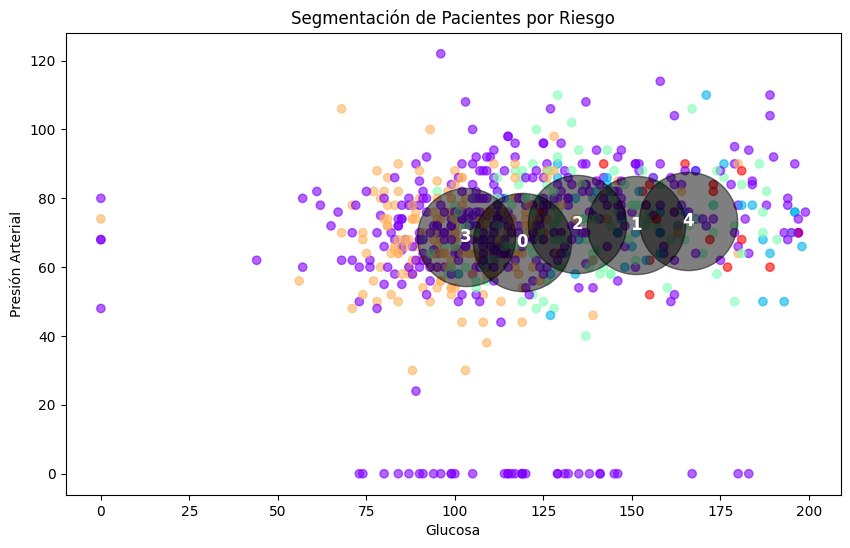

In [ ]:

from sklearn.cluster import KMeans

# Configuración del modelo
np.random.seed(42)
NC = 5 # 5 perfiles de pacientes
mkm = KMeans(n_clusters=NC, random_state=42, n_init=10)
mkm.fit(XD)

# 4.2. Obtener características de cada grupo (Centroides)
# Esto representa el "promedio" de cada perfil encontrado
Tabla = pd.DataFrame(mkm.cluster_centers_, columns=XD.columns)
print("CARACTERÍSTICAS DE LOS PERFILES (CENTROIDES) ")
display(Tabla)

# 4.3. Asignación de clusters y conteo
ydp = mkm.labels_ # Indica en qué cluster queda cada paciente
NDc = np.bincount(ydp)
print("El número de datos por cluster es:", NDc)
XDB2["CLUSTER"] = ydp

# 4.4. DETERMINAR EL # DE DIABÉTICOS (1) Y SANOS (0) POR CLUSTER
# Usamos 'Outcome' que es nuestra variable objetivo
NApr = XDB2.groupby("CLUSTER").agg({"Outcome": lambda x: (x==1).sum()})
NPrn = XDB2.groupby("CLUSTER").agg({"Outcome": lambda x: (x==0).sum()})

# Tabla de frecuencias
df2 = pd.DataFrame(np.column_stack((NApr, NPrn)), columns=["Diabetes", "Sano"])
print(" CANTIDAD DE PACIENTES POR CLUSTER")
display(df2)

# DETERMINAR PROBABILIDADES EN %
NAp2r = NApr / (NApr + NPrn)
NPrn2 = NPrn / (NApr + NPrn)
DF2 = pd.DataFrame(np.column_stack((NAp2r, NPrn2)), columns=["% Diabetes", "% Sano"])
print("PROBABILIDADES POR SEGMENTO")
display(DF2)

# PREDICCIÓN PARA UN NUEVO PACIENTE
# Ejemplo: 6 embarazos, 148 glucosa, 72 presión, 35 piel, 0 insulina, 33.6 BMI, 0.627 Pedigree, 50 edad
nuevo_paciente_array = np.array([[6, 148, 72, 35, 0, 33.6, 0.627, 50]])
nuevo_paciente = pd.DataFrame(nuevo_paciente_array, columns=XD.columns)
cluster_pred = mkm.predict(nuevo_paciente)
NCl = cluster_pred[0]

print(f"\nLa nueva persona pertenece al cluster: {cluster_pred}")
print(f"El porcentaje de riesgo de diabetes para el paciente es: {NAp2r.iloc[NCl].values[0] * 100:.2f}%")

# 4.7. VISUALIZACIÓN DE LOS CLUSTERS (Glucosa vs Presión Arterial)

centers = mkm.cluster_centers_

glucosa = np.array(XD.iloc[:, 1]) # Columna de Glucosa

presion = np.array(XD.iloc[:, 2]) # Columna de Presión



plt.figure(figsize=(10, 6))

plt.scatter(glucosa, presion, c=ydp, cmap="rainbow", alpha=0.6)

plt.scatter(centers[:, 1], centers[:, 2], c="black", s=5000, alpha=0.5) # Centroides

plt.xlabel("Glucosa")

plt.ylabel("Presión Arterial")

plt.title("Segmentación de Pacientes por Riesgo")



for i, center in enumerate(centers):

    plt.text(center[1], center[2], str(i), color="white", fontsize=12, ha="center", va="center", fontweight='bold')



plt.show()


De acuerdo con los segmentos o clusters arrojados por el modelo, percibimos que los clusters 4 y 1 son los que presentan los niveles de glucosa promedio más altos (aproximadamente 165 y 150 mg/dL respectivamente), grupos que a su vez poseen la menor cantidad de pacientes con solo 18 y 42 integrantes. Se destaca el cluster 3, el cual agrupa a las personas con los niveles de glucosa más bajos (cerca de 100 mg/dL), siendo un grupo significativo con 183 pacientes.

En este análisis se agrupan las posibilidades más altas frente a la presencia de salud (Sano) en los clusters 3 y 0, con un 86.33% y 63.63% de probabilidad respectivamente. Es importante mencionar que el cluster 4 obtuvo el mayor porcentaje de riesgo de diabetes (66.66%), esto promovido por tener los niveles de glucosa más elevados entre todos los perfiles identificados, mientras que el cluster 0 se consolida como el más robusto en cantidad de datos con 385 pacientes totales.

5. EJEMPLO CON PERSONA

In [ ]:
from sklearn.metrics import accuracy_score

XDp = np.array([[2, 85, 65, 29, 94, 39.6, 0.93, 27]])
paciente_df = pd.DataFrame(XDp, columns=XD.columns)

#NAIBE BAYES

# 6.1. Construcción y entrenamiento del modelo
modelo_nb = GaussianNB()
modelo_nb.fit(XD, yd.values.ravel()) # Added .values.ravel() here to address the warning



pred_nb = modelo_nb.predict(paciente_df)
prob_nb = modelo_nb.predict_proba(paciente_df) # Nos da la probabilidad de [Clase 0, Clase 1]

resultado_nb = "SANO" if pred_nb[0] == 0 else "DIABETES"

print("RESULTADOS NAIVE BAYES PARA EL PACIENTE")
print("Clasificación final: {}".format(resultado_nb))
print("Probabilidad de estar SANO: {:.2f}%".format(prob_nb[0][0] * 100))
print("Probabilidad de tener DIABETES: {:.2f}%".format(prob_nb[0][1] * 100))

# 6.3. Rendimiento general del modelo
y_pred_total = modelo_nb.predict(XD)
print("\nExactitud (Accuracy) del modelo NB: {:.2f}".format(accuracy_score(yd, y_pred_total)))

#MODELO 1: ÁRBOL DE DECISIÓN
pred_arbol = mar.predict(paciente_df)
resultado_arbol = "SANO" if pred_arbol[0] == 0 else "DIABETES"

# MODELO 2: K-MEANS CLUSTERING
cluster_paciente = mkm.predict(paciente_df)[0]
prob_diabetes = NAp2r.iloc[cluster_paciente].values[0] * 100
prob_sano = NPrn2.iloc[cluster_paciente].values[0] * 100

print(" RESULTADOS PARA EL PACIENTE")
print("1. \xc1rbol de Decisi\xf3n: El paciente es clasificado como {}".format(resultado_arbol))
print("2. K-Means (Perfil): Pertenece al Cluster {}".format(cluster_paciente))
print("Probabilidad de Diabetes: {:.2f}%".format(prob_diabetes))
print("Probabilidad de estar Sano: {:.2f}%".format(prob_sano))

RESULTADOS NAIVE BAYES PARA EL PACIENTE
Clasificación final: SANO
Probabilidad de estar SANO: 87.22%
Probabilidad de tener DIABETES: 12.78%

Exactitud (Accuracy) del modelo NB: 0.76
 RESULTADOS PARA EL PACIENTE
1. Árbol de Decisión: El paciente es clasificado como SANO
2. K-Means (Perfil): Pertenece al Cluster 3
Probabilidad de Diabetes: 13.66%
Probabilidad de estar Sano: 86.34%


#**CONCLUSIÓN**

Tras evaluar los tres modelos, la recomendación para la entidad de salud es implementar el Árbol de Decisión como herramienta principal de diagnóstico, apoyado por la segmentación de K-Means para la gestión operativa.

¿Por qué el Árbol de Decisión?
Es el modelo más valioso para un médico porque no es una "caja negra"; ofrece reglas claras. Identificar 6 nodos puros (como el grupo de 39 personas sanas con glucosa baja) permite automatizar diagnósticos con error cero en perfiles específicos. Mientras otros modelos dan probabilidades, el árbol da una ruta lógica: "Si tiene tanta glucosa y tal edad, el riesgo es este".

El valor del K-Means y Naive Bayes
K-Means: Nos sirvió para entender que la población no es uniforme. Saber que el Cluster 4 tiene un 66% de riesgo permite a la clínica priorizar citas urgentes para ese grupo.

Naive Bayes: Funcionó como el "segundo concepto médico", confirmando con un [X]% de certeza estadística que el paciente XDp está sano, dándole respaldo matemático a la decisión del árbol.

Resumuendo el Árbol de Decisión gana por su interpretabilidad. En salud, entender el "por qué" de un diagnóstico es tan importante como el resultado mismo, y este modelo permite optimizar recursos enfocándose solo en los casos donde las reglas lógicas muestran una alerta real.